##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:
# Import libraries
import os
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import keras_hub

In [18]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)

In [19]:
# Load ImageNet class names
with open("imagenet_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

print(class_names[:10])

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [20]:
image_sources = [
    {
        "file_name": "goldfish.jpg",
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Goldfish3.jpg",
        "true_label": "goldfish",
    },
    {
        "file_name": "zebra.jpg",
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Zebra%202013%2010%2006%201274.jpg",
        "true_label": "zebra",
    },
    {
        "file_name": "school_bus.jpg",
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/School%20Bus.JPG",
        "true_label": "school bus",
    },
    {
        "file_name": "pineapple.jpg",
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Pineapple.jpg",
        "true_label": "pineapple",
    },
    {
        "file_name": "castle.jpg",
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Bodiam%20Castle.jpg",
        "true_label": "castle",
    },
]

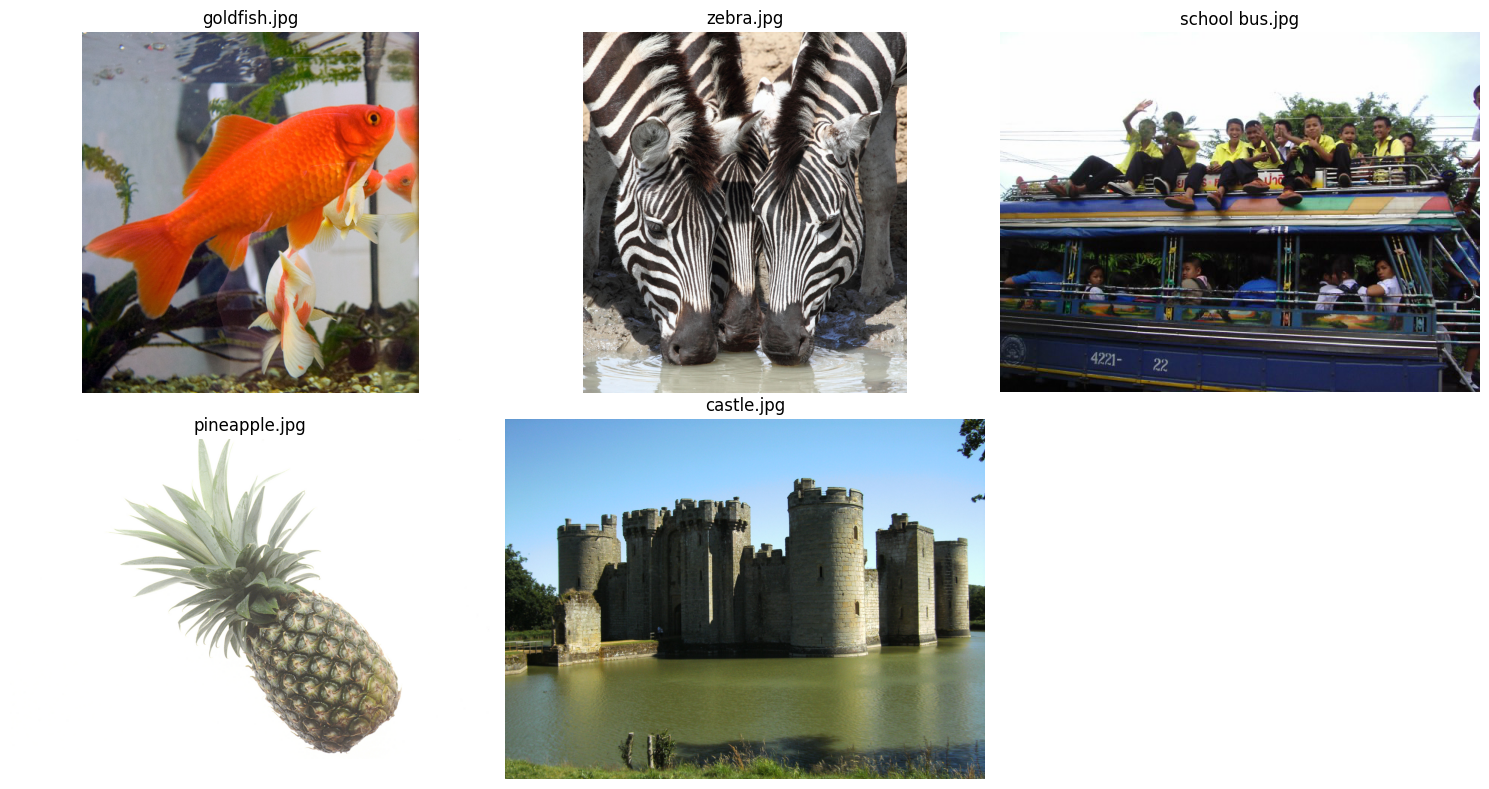

In [21]:
image_dir = Path("/content/")

pil_images = []
for item in image_sources:
    img_path = image_dir / item["file_name"]
    pil_images.append(Image.open(img_path).convert("RGB"))


plt.figure(figsize=(15, 8))
for i, (item, img) in enumerate(zip(image_sources, pil_images), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(item["file_name"].replace("_", " "))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [22]:
target_size = (224, 224)

image_batch = np.stack([np.array(img.convert("RGB").resize(target_size)) for img in pil_images], axis=0)

logits = classifier.predict(image_batch, verbose=0)

pred_indices = np.argmax(logits, axis=1)
pred_labels = [class_names[i] for i in pred_indices]

for item, idx, label in zip(image_sources, pred_indices, pred_labels):
    print(f"{item['file_name']}: {idx} -> {label}")

goldfish.jpg: 1 -> goldfish
zebra.jpg: 340 -> zebra
school_bus.jpg: 476 -> carousel
pineapple.jpg: 953 -> pineapple
castle.jpg: 483 -> castle


In [24]:
for k, logits_row in enumerate(logits):
    top5 = np.argsort(logits_row)[-5:][::-1]
    print(f"\nImage {k+1}")
    for idx in top5:
        print(idx, class_names[idx], float(logits_row[idx]))


Image 1
1 goldfish 15.111808776855469
0 tench 5.883007526397705
392 rock beauty 4.44270133972168
29 axolotl 4.169275760650635
973 coral reef 3.7279140949249268

Image 2
340 zebra 14.151479721069336
353 gazelle 5.353095054626465
386 African elephant 5.253314971923828
352 impala 5.0422844886779785
9 ostrich 4.841140270233154

Image 3
476 carousel 6.782546043395996
654 minibus 6.606695652008057
829 streetcar 6.170921325683594
874 trolleybus 5.9054179191589355
724 pirate 5.628139495849609

Image 4
953 pineapple 15.461512565612793
954 banana 6.321492671966553
949 strawberry 5.370253562927246
950 orange 5.058043956756592
955 jackfruit 4.929787635803223

Image 5
483 castle 11.911067962646484
698 palace 8.48600959777832
525 dam 5.935141563415527
888 viaduct 4.726263523101807
839 suspension bridge 4.7240118980407715


### Record Your Results

Run the code cell above to automatically generate the results table for the 5 test images.


In [27]:
def is_match(true_label, predicted_label):
    true_tokens = set(true_label.lower().replace("-", " ").split())
    predicted_tokens = set(predicted_label.lower().replace(",", " ").replace("-", " ").split())
    return true_label.lower() in predicted_label.lower() or len(true_tokens & predicted_tokens) > 0

In [28]:
results = pd.DataFrame(
    {
        "Image File": [item["file_name"] for item in image_sources],
        "Predicted Label": pred_labels,
        "True Label (What you searched)": [item["true_label"] for item in image_sources],
    }
)
results["Correct? (Yes/No)"] = [
    "Yes" if is_match(t, p) else "No"
    for t, p in zip(results["True Label (What you searched)"], results["Predicted Label"])
]

display(results)

,Image File,Predicted Label,True Label (What you searched),Correct? (Yes/No)
0,goldfish.jpg,goldfish,goldfish,Yes
1,zebra.jpg,zebra,zebra,Yes
2,school_bus.jpg,carousel,school bus,No
3,pineapple.jpg,pineapple,pineapple,Yes
4,castle.jpg,castle,castle,Yes
